Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits
0,2010-06-29 00:00:00-04:00,1.266667,1.666667,1.169333,1.592667,281494500,0.0,0.0
1,2010-06-30 00:00:00-04:00,1.719333,2.028000,1.553333,1.588667,257806500,0.0,0.0
2,2010-07-01 00:00:00-04:00,1.666667,1.728000,1.351333,1.464000,123282000,0.0,0.0
3,2010-07-02 00:00:00-04:00,1.533333,1.540000,1.247333,1.280000,77097000,0.0,0.0
4,2010-07-06 00:00:00-04:00,1.333333,1.333333,1.055333,1.074000,103003500,0.0,0.0


,Date,Revenue
48,2010-09-30,31
49,2010-06-30,28
50,2010-03-31,21
52,2009-09-30,46
53,2009-06-30,27


,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits
0,2002-02-13 00:00:00-05:00,1.620128,1.693350,1.603296,1.691666,76216000,0.0,0.0
1,2002-02-14 00:00:00-05:00,1.712707,1.716074,1.670626,1.683250,11021600,0.0,0.0
2,2002-02-15 00:00:00-05:00,1.683251,1.687459,1.658002,1.674834,8389600,0.0,0.0
3,2002-02-19 00:00:00-05:00,1.666418,1.666418,1.578047,1.607504,7410400,0.0,0.0
4,2002-02-20 00:00:00-05:00,1.615920,1.662209,1.603295,1.662209,6892800,0.0,0.0


,Date,Revenue
57,2006-01-31,1667
58,2005-10-31,534
59,2005-07-31,416
60,2005-04-30,475
61,2005-01-31,709


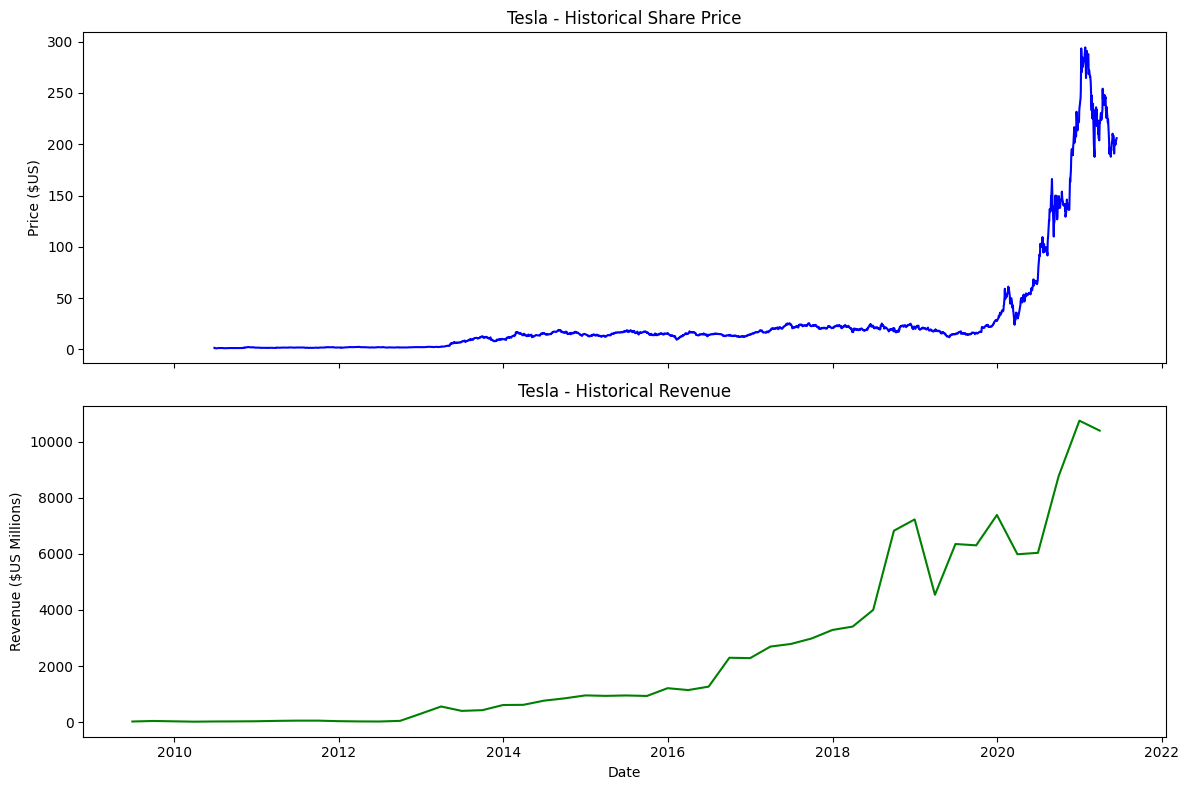

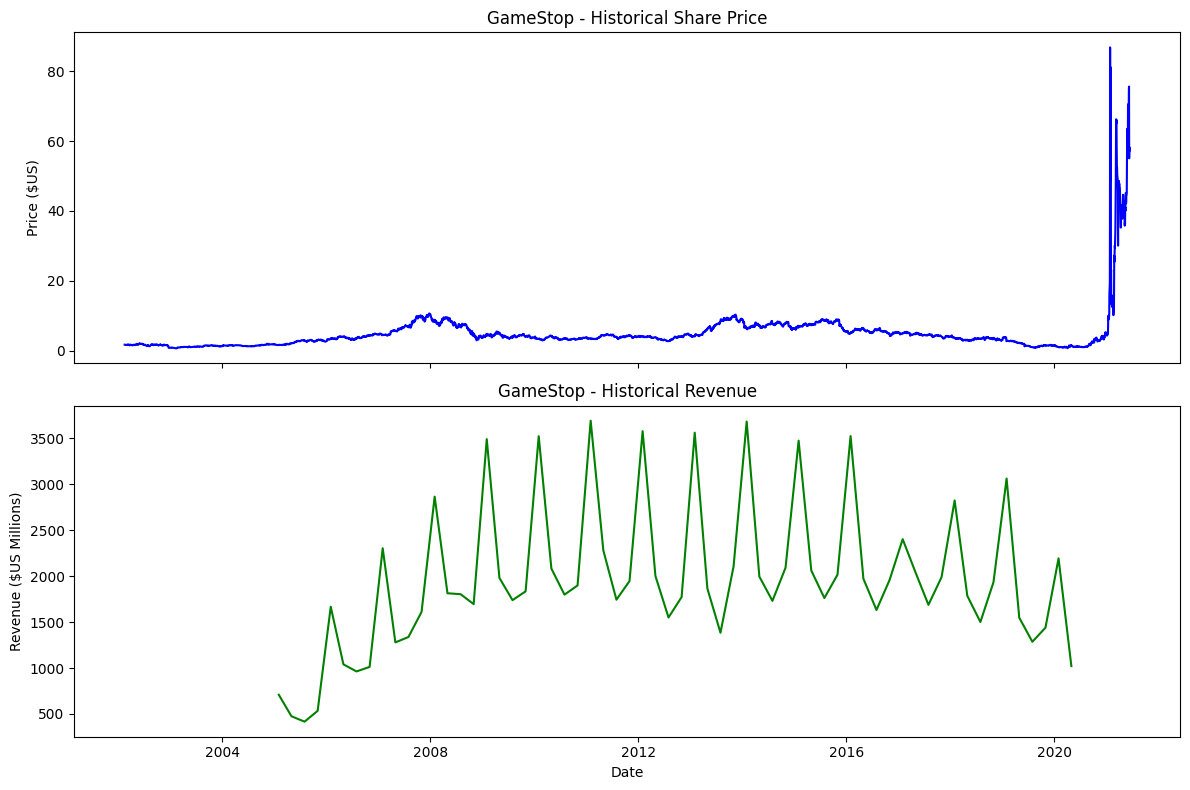

In [2]:
# %% [markdown]
# # Assignment: Extracting and Visualizing Stock Data
# %%
%pip install yfinance pandas requests bs4 lxml html5lib matplotlib

# %% [markdown]
# ### Célula 2: Importações e Configurações
# %%
import yfinance as yf
import pandas as pd
import requests
from bs4 import BeautifulSoup
import matplotlib.pyplot as plt
import warnings
import io

# Ignorar avisos de depreciação do Pandas para deixar a saída limpa
warnings.filterwarnings("ignore", category=FutureWarning)

# %% [markdown]
# ### Define Graphing Function
# %%
def make_graph(stock_data, revenue_data, stock):
    stock_data_specific = stock_data[stock_data.Date <= '2021-06-14']
    revenue_data_specific = revenue_data[revenue_data.Date <= '2021-04-30']

    fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

    # Gráfico de Preço da Ação
    axes[0].plot(pd.to_datetime(stock_data_specific.Date), stock_data_specific.Close.astype("float"), label="Share Price", color="blue")
    axes[0].set_ylabel("Price ($US)")
    axes[0].set_title(f"{stock} - Historical Share Price")

    # Gráfico de Receita
    axes[1].plot(pd.to_datetime(revenue_data_specific.Date), revenue_data_specific.Revenue.astype("float"), label="Revenue", color="green")
    axes[1].set_ylabel("Revenue ($US Millions)")
    axes[1].set_xlabel("Date")
    axes[1].set_title(f"{stock} - Historical Revenue")

    plt.tight_layout()
    plt.show()

# %% [markdown]
# ### Question 1: Use yfinance to Extract Stock Data
# %%
tesla = yf.Ticker("TSLA")
tesla_data = tesla.history(period="max")
tesla_data.reset_index(inplace=True)
display(tesla_data.head())

# %% [markdown]
# ### Question 2: Use Webscraping to Extract Tesla Revenue Data
# %%
url_tesla = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-PY0220EN-SkillsNetwork/labs/project/revenue.htm"
html_data = requests.get(url_tesla).text
soup_tesla = BeautifulSoup(html_data, "html.parser")

tesla_revenue = pd.read_html(io.StringIO(str(soup_tesla)), flavor='bs4')[1]
tesla_revenue.columns = ["Date", "Revenue"]

tesla_revenue["Revenue"] = tesla_revenue['Revenue'].str.replace(r'[\$,]', '', regex=True)
tesla_revenue.dropna(inplace=True)
tesla_revenue = tesla_revenue[tesla_revenue['Revenue'] != ""]
display(tesla_revenue.tail())

# %% [markdown]
# ### Question 3: Use yfinance to Extract Stock Data
# %%
gamestop = yf.Ticker("GME")
gme_data = gamestop.history(period="max")
gme_data.reset_index(inplace=True)
display(gme_data.head())

# %% [markdown]
# ### Question 4: Use Webscraping to Extract GME Revenue Data
# %%
url_gme = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-PY0220EN-SkillsNetwork/labs/project/stock.html"
html_data_2 = requests.get(url_gme).text
soup_gme = BeautifulSoup(html_data_2, "html.parser")

gme_revenue = pd.read_html(io.StringIO(str(soup_gme)), flavor='bs4')[1]
gme_revenue.columns = ["Date", "Revenue"]

gme_revenue["Revenue"] = gme_revenue['Revenue'].str.replace(r'[\$,]', '', regex=True)
gme_revenue.dropna(inplace=True)
gme_revenue = gme_revenue[gme_revenue['Revenue'] != ""]
display(gme_revenue.tail())

# %% [markdown]
# ### Question 5: Plot Tesla Stock Graph
# %%
make_graph(tesla_data, tesla_revenue, 'Tesla')

# %% [markdown]
# ### Question 6: Plot GameStop Stock Graph
# %%
make_graph(gme_data, gme_revenue, 'GameStop')